In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse.csgraph import shortest_path
from sklearn.datasets import load_digits, make_s_curve, make_swiss_roll
from sklearn.manifold import Isomap
from sklearn.neighbors import BallTree
from tqdm.auto import tqdm

plt.style.use("ggplot")
plt.style.use("seaborn-v0_8-colorblind")

# Datasets

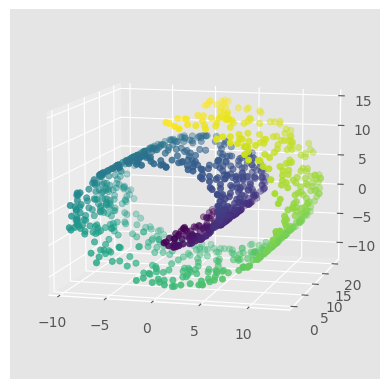

In [3]:
# digits = load_digits()
# data = digits['data']
# labels = digits['target']
# n = data.shape[0]
# data /= 255.0

data, labels = make_swiss_roll(1000)
n = data.shape[0]

# data, labels = make_s_curve(2000)
# n = data.shape[0]

ax = plt.figure().add_subplot(projection="3d")
ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=labels)
ax.view_init(elev=10.0, azim=-75, roll=0)

# Sklearn reference

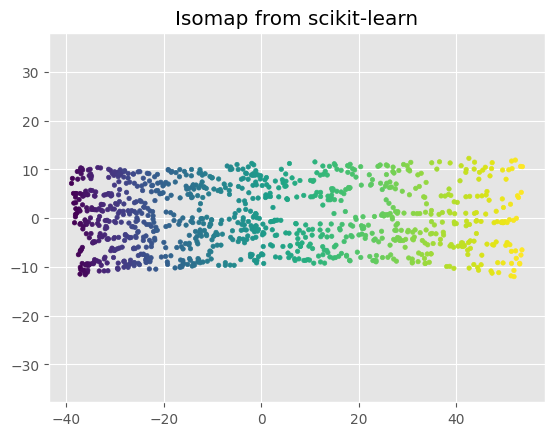

In [4]:
isomap = Isomap(n_neighbors=10)
xy = isomap.fit_transform(data)
plt.scatter(xy[:, 0], xy[:, 1], s=10, c=labels, cmap="viridis")
plt.axis("equal")
plt.title('Isomap from scikit-learn')
plt.show()

## Step 1: Neighbor Graph

In [18]:
def euclidean_pairwise_distance(data):
    """
    Parameters
    ----------
    data : np.ndarray of shape (n, m)
        Data matrix containing n samples, each with m dimensions.
    
    Returns
    -------
    distances : np.ndarray of shape (n, n)
        Pairwise distance matrix, where entry (i, j) gives the distance
        between samples i and j.
    """
    n = data.shape[0]
    
    distances = np.zeros([n, n])
    for i in tqdm(range(n)):
        for j in range(i+1, n):
            dist = np.linalg.norm(data[i] - data[j])
            distances[i, j] = dist
            distances[j, i] = dist
    return distances


def compute_graph(data, k=15, r=None):
    """
    Parameters
    ----------
    data : np.ndarray of shape (n, m)
        Data matrix containing n samples, each with m dimensions.
    
    Returns
    -------
    graph_adj_matrix : np.ndarray of shape (n, n)
        Graph adjacency matrix in which each nonzero entry (i, j) stores the
        distance between connected samples i and j. Entries with value 0 indicate
        that no edge exists between the corresponding samples.
    """
    n = data.shape[0]
    euclidean_pdist = euclidean_pairwise_distance(data)
    
    graph_adj_matrix = np.zeros([n,n]) 
    
    if r is not None:
        mask = (euclidean_pdist <= r) & ~np.eye(n, dtype=bool)
        graph_adj_matrix[mask] = euclidean_pdist[mask]
    else:
        graph_adj_matrix = np.zeros([n,n])
        for i in tqdm(range(n)):
            knn_indices = np.argsort(euclidean_pdist[i])[:k+1]
            for j in knn_indices:
                if i != j:
                    graph_adj_matrix[i, j] = euclidean_pdist[i, j]
                    graph_adj_matrix[j, i] = euclidean_pdist[i, j]
        pass
    return graph_adj_matrix


graph_adj_matrix = compute_graph(data, k=10)
graph_adj_matrix

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1000, 1000))

## Step 2: Shortest Path (given)

In [14]:
shortest_path_distance = shortest_path(graph_adj_matrix)
shortest_path_distance

array([[ 0.        , 16.34220987, 49.74452827, ..., 47.73906434,
        20.79562932, 23.58881927],
       [16.34220987,  0.        , 38.01494266, ..., 37.44902177,
         6.10542079,  7.42261575],
       [49.74452827, 38.01494266,  0.        , ...,  5.3941507 ,
        32.0981615 , 32.1612671 ],
       ...,
       [47.73906434, 37.44902177,  5.3941507 , ...,  0.        ,
        31.5453186 , 32.78789681],
       [20.79562932,  6.10542079, 32.0981615 , ..., 31.5453186 ,
         0.        ,  4.18662985],
       [23.58881927,  7.42261575, 32.1612671 , ..., 32.78789681,
         4.18662985,  0.        ]], shape=(1000, 1000))

## Step 3: Classical MDS (given)

In [15]:
def classical_mds(pdist, n_components=2):
    n = pdist.shape[0]
    h = -np.ones([n, n]) / n + np.eye(n)
    sim = -1 / 2 * h @ pdist**2 @ h
    try:
        svd = np.linalg.svd(sim)
        xy = svd.U[:, :n_components] * svd.S[:n_components] ** 0.5
    except Exception as e:
        print(e)
        xy = np.random.randn(n,2)
    return xy

xy = classical_mds(shortest_path_distance)
xy.shape

(1000, 2)

## Plot

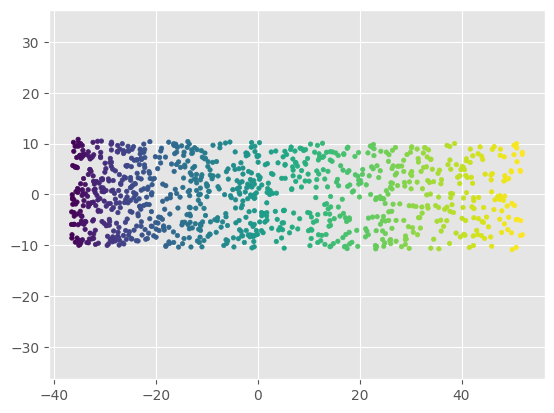

In [17]:
plt.scatter(xy[:, 0], xy[:, 1], s=10, c=labels, cmap="viridis")
plt.axis("equal")
plt.show()